In [29]:
import pandas as pd
import umap
import umap.plot
import matplotlib.pyplot as plt

In [10]:
base_model_path = '/neurospin/dico/data/deep_folding/current/models/Champollion_V0'
bdd_path = f'{base_model_path}/SC-sylv_right/11-43-38_3/ukb40_random_epoch100_embeddings/full_embeddings.csv'

bdd_ukb = pd.read_csv(bdd_path, index_col=0) 
bdd_ukb

,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,dim10,...,dim247,dim248,dim249,dim250,dim251,dim252,dim253,dim254,dim255,dim256
ID,,,,,,,,,,,,,,,,,,,,,
sub-1000021,-37.629620,6.583590,29.279840,-16.611984,-30.081190,-24.476210,11.042302,-6.784241,19.132568,10.150197,...,-2.848078,11.085325,-12.354747,-76.037210,-8.468971,-29.602938,-24.906027,-16.344492,7.703534,-1.050617
sub-1000325,11.934219,11.355382,-13.496794,-38.996407,14.297873,-5.811631,6.174108,-45.331050,9.762536,44.107750,...,4.212949,6.075599,-36.018467,-134.833560,26.447592,-35.490543,4.641970,-4.289551,-58.478560,-31.515226
sub-1000458,-25.394463,4.755465,-22.513622,-25.682335,-67.619896,-18.027046,-30.610876,51.657852,-18.840885,-7.459018,...,-9.459454,-0.912658,32.695583,12.509913,10.790437,-25.991050,-39.407890,-13.558734,47.675068,-0.354762
sub-1000575,-25.367662,-23.005732,-30.035063,36.237038,-103.579190,-9.643719,4.125421,34.603440,19.479185,-13.243917,...,20.220034,-5.049628,4.961305,-25.468930,25.991018,3.052118,-73.673270,6.855866,30.889896,43.402153
sub-1000606,-35.599197,-2.058082,26.222765,-3.495081,-49.495464,-3.061627,-14.236676,-3.899254,-15.054834,50.399190,...,8.652889,27.369568,34.453293,-73.026400,40.409150,28.420736,-51.241203,17.027500,-0.707319,-20.734170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sub-6023847,-37.472730,15.076828,40.302013,14.211771,-52.055767,-15.010591,24.076330,3.206335,-1.258591,3.071922,...,-27.618910,-8.819694,-1.909710,-5.518399,5.431972,28.059300,-48.179085,-25.551464,16.702429,83.777750
sub-6024038,-42.081875,-9.341934,9.514158,0.258455,-50.931040,-28.246084,15.095071,26.785662,0.647673,-32.062424,...,12.599731,18.422710,36.767235,-8.001195,41.257580,1.825518,-52.350716,-10.308723,0.672867,34.854374
sub-6024150,-33.061190,3.562302,41.779350,-38.799210,-13.047621,-14.812035,11.580236,-15.779822,14.094276,23.860043,...,-1.073854,25.488443,-39.752476,-69.233630,-33.353798,-20.189638,24.925224,-8.327268,-22.792067,-12.492115


In [6]:
labelled_CS = pd.read_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/interrupted_SC_labelled.csv')
labelled_CS

,ID,Interruption
0,sub-1376904,1
1,sub-3694216,1
2,sub-1037052,1
3,sub-3250551,1
4,sub-5401486,1
...,...,...
520,sub-1340306,0
521,sub-1691707,0
522,sub-3314602,0
523,sub-5412919,0


In [41]:
list_interrupted_CS = labelled_CS[labelled_CS.Interruption==1].ID.to_list()
list_color = ['g' if i not in list_interrupted_CS else 'r' for i in bdd_ukb.index]
list_size = [0.3 if i not in list_interrupted_CS else 30 for i in bdd_ukb.index]
list_label = ['NO int' if i not in list_interrupted_CS else 'Interrupted' for i in bdd_ukb.index]

In [39]:
umap_reducer = umap.UMAP(densmap=True, random_state=42)

umap_reducer.fit(bdd_ukb)
embedding2D_ukb = umap_reducer.transform(bdd_ukb)

/casa/home/.local/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


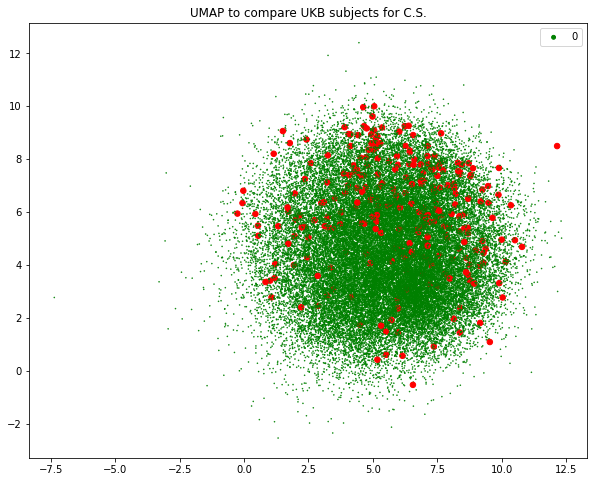

In [43]:
plt.figure(figsize=(10,8))
plt.scatter(embedding2D_ukb[:,0], embedding2D_ukb[:,1], c=list_color, s=list_size)
plt.title('UMAP to compare UKB subjects for C.S.')
plt.legend()
plt.show()

/casa/home/.local/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


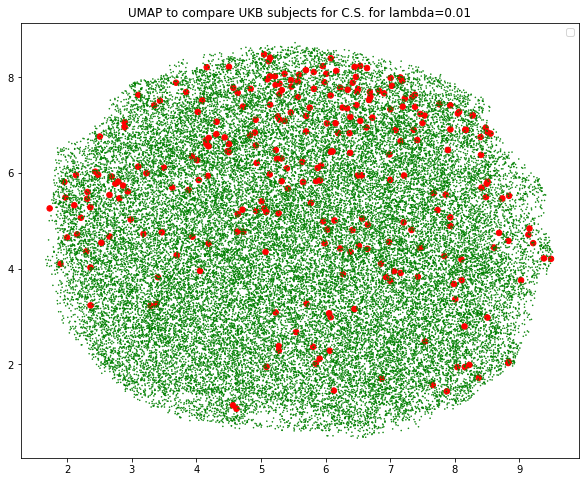

/casa/home/.local/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


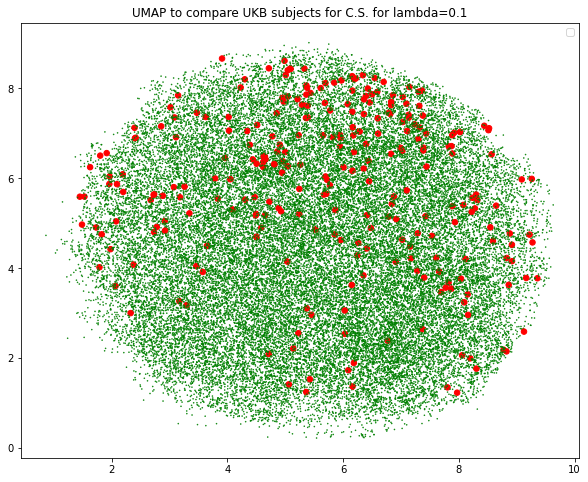

/casa/home/.local/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


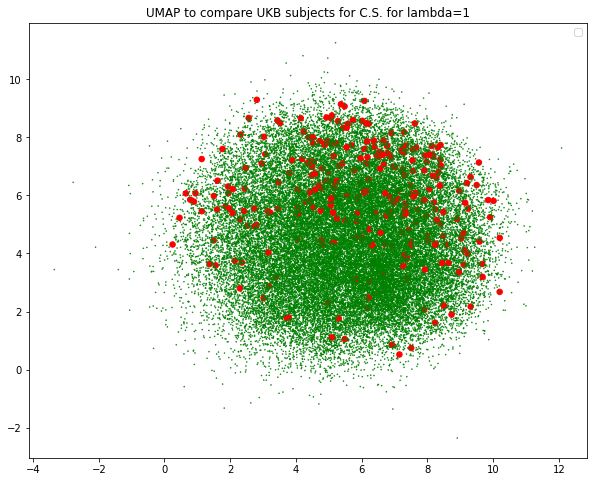

/casa/home/.local/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


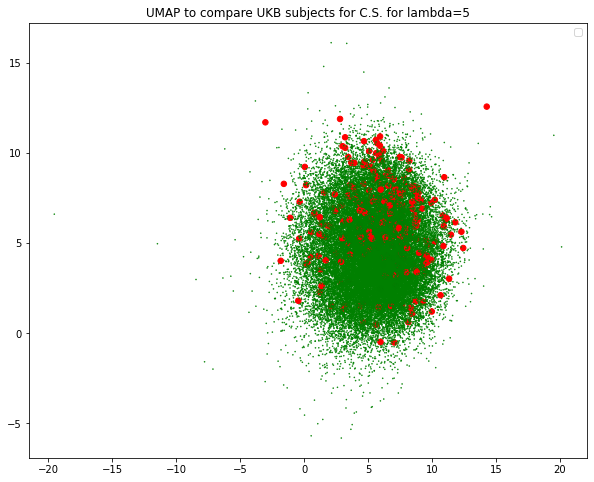

/casa/home/.local/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


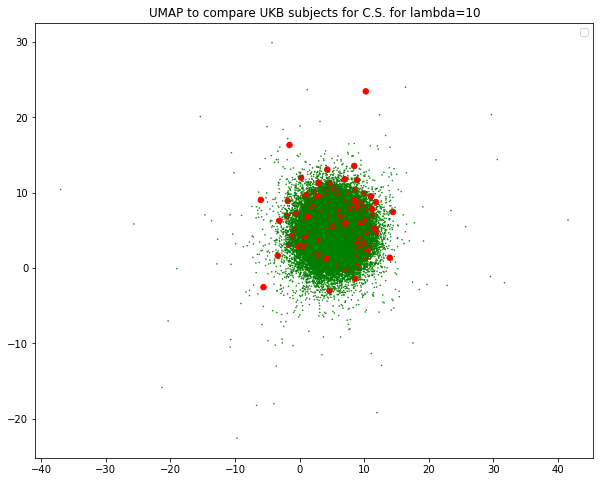

In [45]:
dens_lambda=[0.01,0.1,1,5,10]
for lambda_i in dens_lambda:
    umap_reducer = umap.UMAP(densmap=True,dens_lambda=lambda_i, random_state=42)

    umap_reducer.fit(bdd_ukb)
    embedding2D_ukb = umap_reducer.transform(bdd_ukb)
    plt.figure(figsize=(10,8))
    plt.scatter(embedding2D_ukb[:,0], embedding2D_ukb[:,1], c=list_color, s=list_size)
    plt.title(f'UMAP to compare UKB subjects for C.S. for lambda={lambda_i}')
    plt.legend()
    plt.show()